# 데이터셋 불러오기

In [161]:
import pandas as pd

df = pd.read_csv('C:/Users/Administrator/Dogyeom(2023.01.01)/KIST_intern/Task1/Control_Nuclear_Spins/initialize13Cspin/file/testdata.csv')
df

,Al,Ap,N,x,z,fun
0,3.484993,0.888483,13.0,1.752885,1.085551,0.032390
1,3.390258,1.763503,9.0,3.184325,2.548000,0.094200
2,1.033954,1.358603,9.0,1.463811,1.138441,0.040758
3,4.255130,0.605356,17.0,2.920000,1.788500,0.046560
4,4.746024,1.083821,13.0,2.770525,1.185844,0.026307
...,...,...,...,...,...,...
7547,3.364601,0.689352,13.0,1.783018,1.094393,0.028112
7548,2.637363,1.368201,9.0,4.273264,2.603631,0.065762
7549,4.689082,1.140467,9.0,4.026179,1.717521,0.060243
7550,1.077035,0.540976,13.0,0.492744,0.200560,0.026543


## 데이터셋 분류

In [162]:
yn = df['N']
yn

0       13.0
1        9.0
2        9.0
3       17.0
4       13.0
        ... 
7547    13.0
7548     9.0
7549     9.0
7550    13.0
7551     9.0
Name: N, Length: 7552, dtype: float64

In [163]:
yx = df['x']
yx

0       1.752885
1       3.184325
2       1.463811
3       2.920000
4       2.770525
          ...   
7547    1.783018
7548    4.273264
7549    4.026179
7550    0.492744
7551    2.902723
Name: x, Length: 7552, dtype: float64

In [164]:
yz = df['z']
yz

0       1.085551
1       2.548000
2       1.138441
3       1.788500
4       1.185844
          ...   
7547    1.094393
7548    2.603631
7549    1.717521
7550    0.200560
7551    1.784943
Name: z, Length: 7552, dtype: float64

In [165]:
X = df[['Al', 'Ap']]
X

,Al,Ap
0,3.484993,0.888483
1,3.390258,1.763503
2,1.033954,1.358603
3,4.255130,0.605356
4,4.746024,1.083821
...,...,...
7547,3.364601,0.689352
7548,2.637363,1.368201
7549,4.689082,1.140467
7550,1.077035,0.540976


## 데이터 학습/테스트 구분

In [166]:
from sklearn.model_selection import train_test_split


Xn_train, Xn_test, yn_train, yn_test = train_test_split(X, yn, test_size=0.2, random_state=100)
Xx_train, Xx_test, yx_train, yx_test = train_test_split(X, yx, test_size=0.2, random_state=100)
Xz_train, Xz_test, yz_train, yz_test = train_test_split(X, yz, test_size=0.2, random_state=100)

# 학습 모델

## KNN regression

In [167]:
from sklearn.neighbors import KNeighborsRegressor

kn = KNeighborsRegressor(n_neighbors = 14, weights = "distance")
knx = KNeighborsRegressor(n_neighbors = 14, weights = "distance")
knz = KNeighborsRegressor(n_neighbors = 14, weights = "distance")

kn.fit(Xn_train, yn_train)
knx.fit(Xx_train, yx_train)
knz.fit(Xz_train, yz_train)

KNeighborsRegressor(n_neighbors=14, weights='distance')

In [168]:
yn_kn_train_pred = kn.predict(Xn_train)
yn_kn_test_pred = kn.predict(Xn_test)

yx_kn_train_pred = knx.predict(Xx_train)
yx_kn_test_pred = knx.predict(Xx_test)

yz_kn_train_pred = knz.predict(Xz_train)
yz_kn_test_pred = knz.predict(Xz_test)

In [169]:
from sklearn.metrics import mean_squared_error, r2_score

kn_train_mse = mean_squared_error(yn_train, yn_kn_train_pred)
kn_train_r2 = r2_score(yn_train, yn_kn_train_pred)

kn_test_mse = mean_squared_error(yn_test, yn_kn_test_pred)
kn_test_r2 = r2_score(yn_test, yn_kn_test_pred)

# Figure

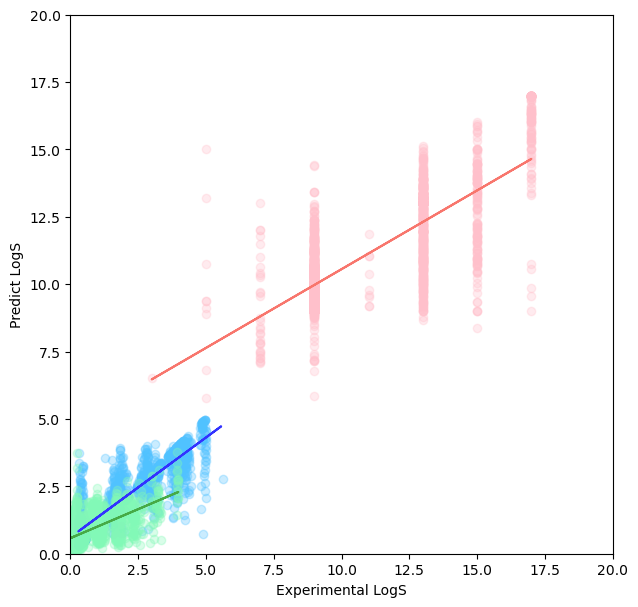

In [170]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,7))
plt.scatter(x=yn_test, y=yn_kn_test_pred, c="#FFC0CB" ,alpha=0.3)

plt.scatter(x=yx_test, y=yx_kn_test_pred, c="#50C2FF" ,alpha=0.3)

plt.scatter(x=yz_test, y=yz_kn_test_pred, c="#82F9B7" ,alpha=0.3)

nn = np.polyfit(yn_test, yn_kn_test_pred, 1)
pn = np.poly1d(nn)

xx = np.polyfit(yx_test, yx_kn_test_pred, 1)
px = np.poly1d(xx)

zz = np.polyfit(yz_test, yz_kn_test_pred, 1)
pz = np.poly1d(zz)

plt.plot(yn_train, pn(yn_train), '#F8766D')
plt.plot(yx_train, px(yx_train), '#3232FF')
plt.plot(yz_train, pz(yz_train), '#46AA46')
plt.ylabel('Predict LogS')
plt.xlabel('Experimental LogS')
plt.ylim(0, 20)
plt.xlim(0, 20)
plt.show()

# train 정확도 측정

## KNN_train 정확도 측정

In [171]:
from sklearn.metrics import mean_squared_error, r2_score

knn_train_mse = mean_squared_error(yn_train, yn_kn_train_pred)
knn_train_r2 = r2_score(yn_train, yn_kn_train_pred)

knn_test_mse = mean_squared_error(yn_test, yn_kn_test_pred)
knn_test_r2 = r2_score(yn_test, yn_kn_test_pred)

knx_train_mse = mean_squared_error(yx_train, yx_kn_train_pred)
knx_train_r2 = r2_score(yx_train, yx_kn_train_pred)

knx_test_mse = mean_squared_error(yx_test, yx_kn_test_pred)
knx_test_r2 = r2_score(yx_test, yx_kn_test_pred)

knz_train_mse = mean_squared_error(yz_train, yz_kn_train_pred)
knz_train_r2 = r2_score(yz_train, yz_kn_train_pred)

knz_test_mse = mean_squared_error(yz_test, yz_kn_test_pred)
knz_test_r2 = r2_score(yz_test, yz_kn_test_pred)

In [172]:
print('KNN MSE (Train): ', knn_train_mse)
print('KNN R2 (Train): ', knn_train_r2)
print('KNN MSE (Test): ', knn_test_mse)
print('KNN R2 (Test): ', knn_test_r2)
print(' ')
print('KNX MSE (Train): ', knx_train_mse)
print('KNX R2 (Train): ', knx_train_r2)
print('KNX MSE (Test): ', knx_test_mse)
print('KNX R2 (Test): ', knx_test_r2)
print(' ')
print('KNZ MSE (Train): ', knz_train_mse)
print('KNZ R2 (Train): ', knz_train_r2)
print('KNZ MSE (Test): ', knz_test_mse)
print('KNZ R2 (Test): ', knz_test_r2)

KNN MSE (Train):  0.0
KNN R2 (Train):  1.0
KNN MSE (Test):  3.145481826142739
KNN R2 (Test):  0.5756925497655554
 
KNX MSE (Train):  0.0
KNX R2 (Train):  1.0
KNX MSE (Test):  0.46822020056679226
KNX R2 (Test):  0.7538769465705591
 
KNZ MSE (Train):  0.0
KNZ R2 (Train):  1.0
KNZ MSE (Test):  0.4480823632015594
KNZ R2 (Test):  0.3756335690914089


# 직접 실험하기

In [185]:
inal = 0.484639
inap = 1.608656
dd = []

dd.append([inal, inap])
df = pd.DataFrame(dd, columns=['Al', 'Ap'])

In [186]:
df

,Al,Ap
0,0.484639,1.608656


In [187]:
dfn = kn.predict(df)
dfx = knx.predict(df)
dfz = knz.predict(df)

In [188]:
print('N val: ', dfn)
print('X tau: ', dfx)
print('Z tau: ', dfz)

N val:  [7.02515099]
X tau:  [3.51692164]
Z tau:  [1.37516887]
